In [59]:
import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import GCNConv
from torch_geometric.utils import from_networkx, negative_sampling
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd
import random

In [60]:
def generate_larger_graph_with_noise():
    G = nx.Graph()
    cycle_edges = []
    cycle_nodes = []
    offset = 0

    # Create two automorphic cycles
    for _ in range(2):
        nodes = list(range(offset, offset + 4))
        edges = [(nodes[i], nodes[(i + 1) % 4]) for i in range(4)]
        G.add_edges_from(edges)
        cycle_edges.extend(edges)
        cycle_nodes.append(nodes)
        offset += 4

    # Connect each cycle node to a unique hub node
    for i in range(8):
        hub = offset + i
        G.add_edge(i, hub)
 
    # Add noise edges between random node pairs
    for _ in range(10):
        u, v = random.sample(G.nodes, 2)
        if not G.has_edge(u, v) and u != v:
            G.add_edge(u, v)

    # Assign constant feature to each node
    for n in G.nodes:
        G.nodes[n]['x'] = [1.0]

    # Visualization
    pos = nx.spring_layout(G, seed=42)

    # Edge coloring
    edge_colors = [
        'red' if (e in cycle_edges or (e[1], e[0]) in cycle_edges) else 'gray'
        for e in G.edges()
    ]

    # Node coloring
    node_colors = []
    for n in G.nodes():
        if n in cycle_nodes[0]:
            node_colors.append('lightcoral')  # first cycle
        elif n in cycle_nodes[1]:
            node_colors.append('lightgreen')  # second cycle
        else:
            node_colors.append('skyblue')     # hub or noise

    plt.figure(figsize=(8, 6))
    nx.draw(
        G, pos, with_labels=True,
        node_color=node_colors,
        edge_color=edge_colors,
        node_size=500,
        width=2.0
    )
    plt.title("Graph with Automorphic Cycles and Noise\n(Red Edges = Automorphic, Gray = Others)")
    plt.show()

    return from_networkx(G), cycle_edges, G


In [61]:
class GCN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

In [62]:
class LinkPredictor(torch.nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.lin = Linear(2 * dim, 1)
    def forward(self, x_i, x_j):
        return torch.sigmoid(self.lin(torch.cat([x_i, x_j], dim=-1))).squeeze(-1)

/scratch/ipykernel_583322/2993630562.py:23: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  u, v = random.sample(G.nodes, 2)


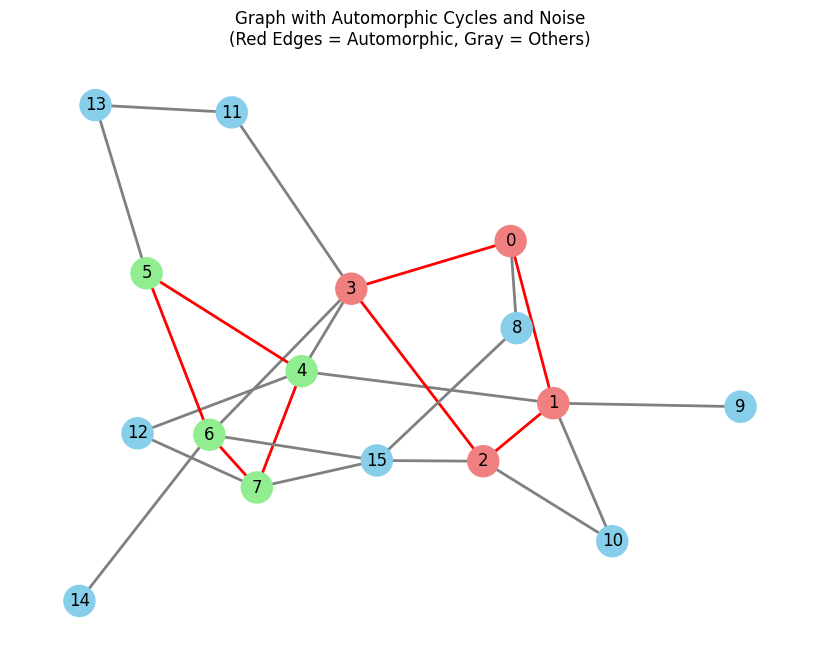

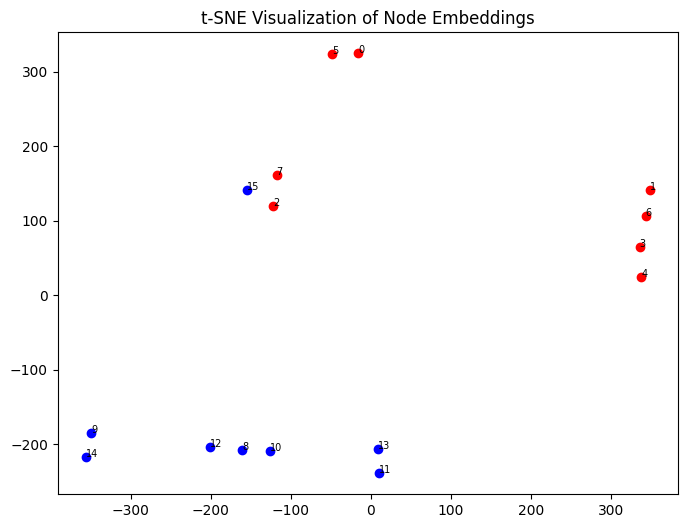

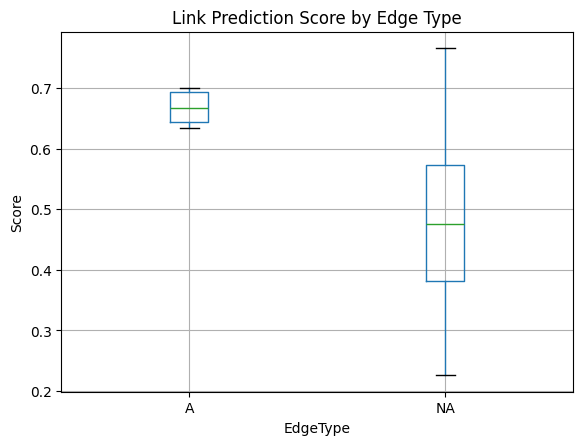

In [63]:
def run():
    data, auto_edges, G = generate_larger_graph_with_noise()
    edge_index = data.edge_index
    data.x = torch.tensor([d['x'] for _, d in G.nodes(data=True)], dtype=torch.float)

    model = GCN(1, 16)
    predictor = LinkPredictor(16)
    optimizer = torch.optim.Adam(list(model.parameters()) + list(predictor.parameters()), lr=0.01)

    neg_edge_index = negative_sampling(edge_index, data.num_nodes, edge_index.size(1))
    all_edge_index = torch.cat([edge_index, neg_edge_index], dim=1)
    labels = torch.cat([torch.ones(edge_index.size(1)), torch.zeros(neg_edge_index.size(1))])

    for _ in range(50):
        model.train()
        x = model(data.x, edge_index)
        src, dst = all_edge_index
        pred = predictor(x[src], x[dst])
        loss = F.binary_cross_entropy(pred, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    x = model(data.x, edge_index).detach()

    # t-SNE for node embeddings
    tsne = TSNE(n_components=2, perplexity=2, random_state=0)
    x_2d = tsne.fit_transform(x.numpy())
    plt.figure(figsize=(8, 6))
    for i, (x_, y_) in enumerate(x_2d):
        color = 'red' if i < 8 else 'blue'
        plt.scatter(x_, y_, c=color)
        plt.text(x_ + 0.01, y_ + 0.01, str(i), fontsize=7)
    plt.title("t-SNE Visualization of Node Embeddings")
    plt.show()


    # Link prediction results
    preds, types = [], []
    for i in range(all_edge_index.size(1)):
        s, d = int(all_edge_index[0, i]), int(all_edge_index[1, i])
        pred = predictor(x[s].unsqueeze(0), x[d].unsqueeze(0)).item()
        typ = 'A' if (s,d) in auto_edges or (d,s) in auto_edges else 'NA'
        preds.append(pred)
        types.append(typ)

    df = pd.DataFrame({"Prediction": preds, "EdgeType": types})
    df.boxplot(column="Prediction", by="EdgeType")
    plt.title("Link Prediction Score by Edge Type")
    plt.suptitle("")
    plt.ylabel("Score")
    plt.show()
    
run()